## Data Loading and Preprocessing (from original notebook)\n

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matminer.datasets import load_dataset
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.conversions import StrToComposition

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


# ── Shared featurization ────────────────────────────────────────────────────

def featurize_compositions(df: pd.DataFrame,
                           composition_col: str = "composition") -> pd.DataFrame:
    """
    Convert a column of composition strings (e.g. 'ZnS') into
    132 numerical MAGPIE features.

    Returns a new DataFrame with feature columns only (no strings).
    """
    # Step 1: convert string → pymatgen Composition object
    stc = StrToComposition(target_col_id="composition_obj")
    df = stc.featurize_dataframe(df, composition_col, ignore_errors=True)

    # Step 2: compute MAGPIE features from Composition objects
    ep = ElementProperty.from_preset("magpie")
    df = ep.featurize_dataframe(df, col_id="composition_obj", ignore_errors=True)

    # Keep only the numeric feature columns
    feature_cols = ep.feature_labels()
    df = df.dropna(subset=feature_cols)   # drop any failed entries

    return df, feature_cols

# ── Shared PyTorch Dataset ──────────────────────────────────────────────────

class MaterialsDataset(Dataset):
    """
    Simple tabular dataset for materials property prediction.

    X: float32 tensor of shape (n_samples, n_features)
    y: float32 tensor of shape (n_samples, 1)
    """

    def __init__(self, X: np.ndarray, y: np.ndarray):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_loader(X, y, batch_size=64, shuffle=True, drop_last=False):
    """Build train and validation DataLoaders."""
    dataset = MaterialsDataset(X, y)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last)
    return loader

In [2]:
import os
import numpy as np

# Nombre del archivo donde guardaremos las matrices
archivo_datos = "datos_entrenamiento_metal.npz"

if os.path.exists(archivo_datos):
    # ==========================================
    # CASO 1: EL ARCHIVO EXISTE -> CARGAMOS RÁPIDO
    # ==========================================
    print("⏳ Archivo encontrado. Cargando datos desde el disco...")

    datos_cargados = np.load(archivo_datos)
    X_cls = datos_cargados["X"]
    y_cls = datos_cargados["y"]

    print(f"✅ ¡Datos cargados al instante! Dimensiones de X: {X_cls.shape}")

else:
    # ==========================================
    # CASO 2: NO EXISTE -> EJECUTAMOS TU CÓDIGO Y GUARDAMOS
    # ==========================================
    print("⚙️ Archivo no encontrado. Calculando features por primera vez (esto puede tardar)...")

    # --- TU CÓDIGO EXACTO AQUÍ ---
    df_metal, feature_cols = featurize_compositions(df_metal, composition_col="composition")

    X_cls = df_metal[feature_cols].values.astype(np.float32)
    y_cls = df_metal["is_metal"].astype(int).values.astype(np.float32)
    # -----------------------------

    print(f"📊 Feature matrix shape: {X_cls.shape}")
    print(f"⚖️ Class balance — metals: {y_cls.mean():.1%} | non-metals: {1-y_cls.mean():.1%}")

    # Guardamos las matrices generadas usando np.savez_compressed (ocupa menos espacio)
    np.savez_compressed(archivo_datos, X=X_cls, y=y_cls)
    print(f"💾 Datos guardados exitosamente en '{archivo_datos}'.")

⏳ Archivo encontrado. Cargando datos desde el disco...
✅ ¡Datos cargados al instante! Dimensiones de X: (4921, 132)


In [3]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42,
    stratify=y_cls    # preserve class balance in both splits
)

X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(
    X_train_c, y_train_c, test_size=0.2, random_state=42,
    stratify=y_train_c
)

scaler_c = StandardScaler()
X_train_c = scaler_c.fit_transform(X_train_c)
X_val_c   = scaler_c.transform(X_val_c)
X_test_c  = scaler_c.transform(X_test_c)

train_loader_c = make_loader(X_train_c, y_train_c, batch_size=64, shuffle=True, drop_last=True)
val_loader_c   = make_loader(X_val_c, y_val_c, batch_size=64, shuffle=False, drop_last=False)
test_loader_c  = make_loader(X_test_c, y_test_c, batch_size=64, shuffle=False, drop_last=False)

# Improved Binary Classification Training + Metrics

This notebook assumes these variables already exist from your data-preparation pipeline:
- `X_train_c, y_train_c`
- `X_val_c, y_val_c`
- `X_test_c, y_test_c`
- `MaterialsDataset`
- `device`


In [4]:
import copy
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, classification_report
)


In [5]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
try:
    torch.use_deterministic_algorithms(True)
except Exception:
    pass


In [6]:
# Deterministic DataLoaders
g = torch.Generator()
g.manual_seed(SEED)

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)

train_loader_c = DataLoader(
    MaterialsDataset(X_train_c, y_train_c),
    batch_size=64,
    shuffle=True,
    drop_last=True,
    worker_init_fn=seed_worker,
    generator=g,
)

val_loader_c = DataLoader(
    MaterialsDataset(X_val_c, y_val_c),
    batch_size=64,
    shuffle=False,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=g,
)

test_loader_c = DataLoader(
    MaterialsDataset(X_test_c, y_test_c),
    batch_size=64,
    shuffle=False,
    drop_last=False,
    worker_init_fn=seed_worker,
    generator=g,
)

print(f"Train: {len(train_loader_c.dataset)} | Val: {len(val_loader_c.dataset)} | Test: {len(test_loader_c.dataset)}")


Train: 3148 | Val: 788 | Test: 985


In [7]:
device = torch.device("cpu")  # For debugging use cpu, because if it fails, CUDA gets blocked and process has to be restarted# Improved architecture (smaller capacity + BatchNorm + Dropout)
class MetalClassifierNetV2(nn.Module):
    def __init__(self, n_features: int, dropout: float = 0.35):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_features, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(32, 2)
        )

    def forward(self, x):
        return self.net(x)


In [8]:
# Train/eval helpers
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for X_batch, y_batch in loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).squeeze().long()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    return total_loss / len(loader)

def evaluate_loss(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device).squeeze().long()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            total_loss += loss.item()
    return total_loss / len(loader)

def collect_predictions(model, loader, device):
    model.eval()
    y_true, y_pred, y_prob = [], [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch_np = y_batch.squeeze().long().cpu().numpy()
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)[:, 1].cpu().numpy()
            preds = torch.argmax(logits, dim=1).cpu().numpy()
            y_true.extend(y_batch_np.tolist())
            y_pred.extend(preds.tolist())
            y_prob.extend(probs.tolist())
    return np.array(y_true), np.array(y_pred), np.array(y_prob)


In [9]:
# Training config + loop (early stopping on val_loss)
model_cls = MetalClassifierNetV2(n_features=132, dropout=0.35).to(device)
criterion_cls = nn.CrossEntropyLoss()
optimizer_cls = optim.AdamW(model_cls.parameters(), lr=1e-3, weight_decay=3e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_cls, mode="min", factor=0.5, patience=3, min_lr=1e-6
)

N_EPOCHS = 60
PATIENCE_EARLY_STOP = 5

history = {"train_loss": [], "val_loss": [], "lr": []}
best_val = float("inf")
best_epoch = -1
best_state = copy.deepcopy(model_cls.state_dict())
epochs_no_improve = 0

for epoch in range(N_EPOCHS):
    train_loss = train_epoch(model_cls, train_loader_c, optimizer_cls, criterion_cls, device)
    val_loss = evaluate_loss(model_cls, val_loader_c, criterion_cls, device)

    scheduler.step(val_loss)
    current_lr = optimizer_cls.param_groups[0]["lr"]

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["lr"].append(current_lr)

    print(f"Epoch {epoch+1:03d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | lr={current_lr:.2e}")

    if val_loss < best_val - 1e-4:
        best_val = val_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model_cls.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1

    if epochs_no_improve >= PATIENCE_EARLY_STOP:
        print(f"Early stopping at epoch {epoch+1}. Best val_loss={best_val:.4f} (epoch {best_epoch+1}).")
        break

model_cls.load_state_dict(best_state)


Epoch 001 | train_loss=0.5140 | val_loss=0.3854 | lr=1.00e-03
Epoch 002 | train_loss=0.3876 | val_loss=0.3389 | lr=1.00e-03
Epoch 003 | train_loss=0.3567 | val_loss=0.3336 | lr=1.00e-03
Epoch 004 | train_loss=0.3467 | val_loss=0.3193 | lr=1.00e-03
Epoch 005 | train_loss=0.3367 | val_loss=0.3081 | lr=1.00e-03
Epoch 006 | train_loss=0.3154 | val_loss=0.2935 | lr=1.00e-03
Epoch 007 | train_loss=0.3087 | val_loss=0.3056 | lr=1.00e-03
Epoch 008 | train_loss=0.3113 | val_loss=0.2939 | lr=1.00e-03
Epoch 009 | train_loss=0.2923 | val_loss=0.3020 | lr=1.00e-03
Epoch 010 | train_loss=0.3026 | val_loss=0.2921 | lr=1.00e-03
Epoch 011 | train_loss=0.2971 | val_loss=0.2956 | lr=1.00e-03
Epoch 012 | train_loss=0.2957 | val_loss=0.2898 | lr=1.00e-03
Epoch 013 | train_loss=0.2765 | val_loss=0.2748 | lr=1.00e-03
Epoch 014 | train_loss=0.2812 | val_loss=0.2966 | lr=1.00e-03
Epoch 015 | train_loss=0.2748 | val_loss=0.2760 | lr=1.00e-03
Epoch 016 | train_loss=0.2753 | val_loss=0.2673 | lr=1.00e-03
Epoch 01

<All keys matched successfully>

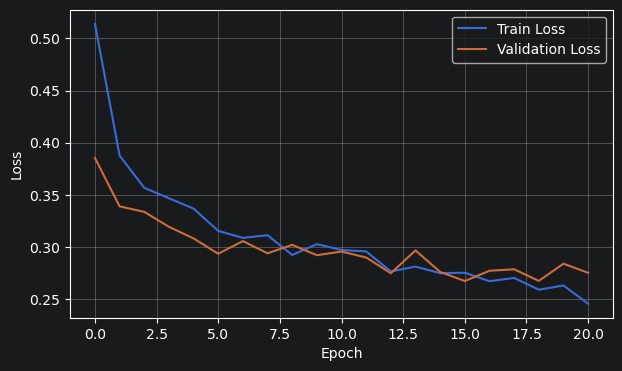

Best val_loss: 0.2673 at epoch 16
Final train_loss: 0.2455
Final val_loss: 0.2752
Generalization gap (final): 0.0296


In [10]:
# Loss curves + val_loss summary
plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

print(f"Best val_loss: {best_val:.4f} at epoch {best_epoch+1}")
print(f"Final train_loss: {history['train_loss'][-1]:.4f}")
print(f"Final val_loss: {history['val_loss'][-1]:.4f}")
print(f"Generalization gap (final): {history['val_loss'][-1]-history['train_loss'][-1]:.4f}")


Test metrics:
Accuracy : 0.8782
Precision: 0.8703
Recall   : 0.8880
F1-score : 0.8790
ROC-AUC  : 0.9566

Classification report:
              precision    recall  f1-score   support

           0     0.8864    0.8684    0.8773       494
           1     0.8703    0.8880    0.8790       491

    accuracy                         0.8782       985
   macro avg     0.8783    0.8782    0.8782       985
weighted avg     0.8783    0.8782    0.8782       985



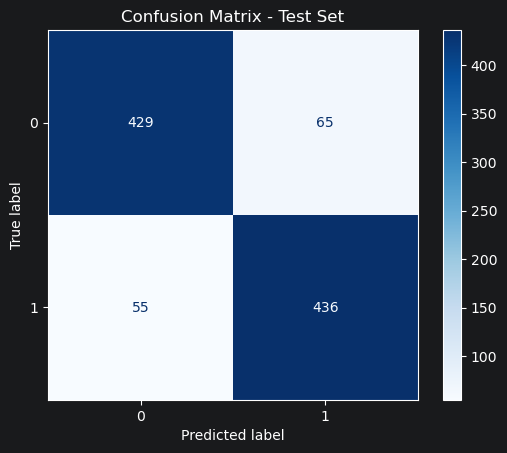

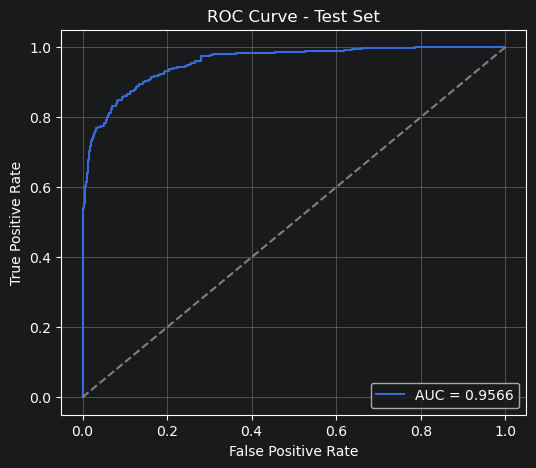

In [11]:
# Test-set classification metrics + plots
y_true, y_pred, y_prob = collect_predictions(model_cls, test_loader_c, device)

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, zero_division=0)
rec = recall_score(y_true, y_pred, zero_division=0)
f1 = f1_score(y_true, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_true, y_prob)

print("Test metrics:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

print("\nClassification report:")
print(classification_report(y_true, y_pred, digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Test Set")
plt.show()

fpr, tpr, _ = roc_curve(y_true, y_prob)
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], "--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Test Set")
plt.legend()
plt.grid(True)
plt.show()


# Small hyperparameter search: dropout, weight_decay, lr, optimizer (Adam vs AdamW)
import copy
import itertools
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score

def fit_with_early_stopping(config, max_epochs=60, patience=5):
    model = MetalClassifierNetV2(n_features=132, dropout=config['dropout']).to(device)

    if config['optimizer'] == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])
    else:
        optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=config['weight_decay'])

    criterion = nn.CrossEntropyLoss()
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6
    )

    best_val = float('inf')
    best_state = copy.deepcopy(model.state_dict())
    no_improve = 0

    for _ in range(max_epochs):
        _ = train_epoch(model, train_loader_c, optimizer, criterion, device)
        val_loss = evaluate_loss(model, val_loader_c, criterion, device)
        scheduler.step(val_loss)

        if val_loss < best_val - 1e-4:
            best_val = val_loss
            best_state = copy.deepcopy(model.state_dict())
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            break

    model.load_state_dict(best_state)

    y_val_true, y_val_pred, y_val_prob = collect_predictions(model, val_loader_c, device)
    return {
        'model': model,
        'val_loss': float(best_val),
        'val_f1': float(f1_score(y_val_true, y_val_pred, zero_division=0)),
        'val_acc': float(accuracy_score(y_val_true, y_val_pred)),
        'val_auc': float(roc_auc_score(y_val_true, y_val_prob)),
    }

search_space = {
    'dropout': [0.25, 0.35, 0.45],
    'weight_decay': [1e-4, 3e-4, 1e-3],
    'lr': [1e-3, 5e-4, 3e-4],
    'optimizer': ['Adam', 'AdamW'],
}

all_configs = list(itertools.product(
    search_space['dropout'],
    search_space['weight_decay'],
    search_space['lr'],
    search_space['optimizer'],
))

results = []
best = None

for i, (dropout, weight_decay, lr, optimizer_name) in enumerate(all_configs, start=1):
    cfg = {
        'dropout': dropout,
        'weight_decay': weight_decay,
        'lr': lr,
        'optimizer': optimizer_name,
    }

    out = fit_with_early_stopping(cfg, max_epochs=60, patience=5)
    row = {**cfg, **{k: v for k, v in out.items() if k != 'model'}}
    results.append(row)

    # Rank: lower val_loss first, then higher val_f1
    if (best is None) or ((row['val_loss'], -row['val_f1']) < (best['val_loss'], -best['val_f1'])):
        best = {**row, 'model': out['model']}

    print(f"[{i:02d}/{len(all_configs)}] {cfg} -> val_loss={row['val_loss']:.4f}, val_f1={row['val_f1']:.4f}, val_auc={row['val_auc']:.4f}")

print('\nBest config found:')
print({k: v for k, v in best.items() if k != 'model'})

# Replace global model with best model for downstream test evaluation cells
model_cls = best['model']

# Optional: summary table sorted by val_loss then val_f1
import pandas as pd
results_df = pd.DataFrame(results).sort_values(['val_loss', 'val_f1'], ascending=[True, False]).reset_index(drop=True)
display(results_df.head(10))
